<a href="https://colab.research.google.com/github/abhaykatiyar023-ak/CodeAlpha_Basic-Chatbot/blob/main/House_Price_Prediction_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Import libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

Cell 2 — upLoad dataset

In [ ]:
from google.colab import files

# uploaded = files.upload()

Cell 3 — Load dataset

In [ ]:
df = pd.read_csv("Housing.csv")
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


Cell 4 — Check dataset

In [ ]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

Missing Values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0


Cell 5 — Convert categorical columns

In [ ]:
# Convert yes/no columns to 0/1
binary_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in binary_columns:
    df[col] = df[col].map({'yes': 1, 'no': 0})

# Convert furnishing status using one-hot encoding
df = pd.get_dummies(
    df,
    columns=['furnishingstatus'],
    drop_first=True
)

print(df.head())
print("New Shape:", df.shape)

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

Cell 6 — Separate features and target

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

print("Features:", X.shape)
print("Target:", y.shape)

Features: (545, 13)
Target: (545,)


Cell 7 — Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


Cell 8 — Train Linear Regression model

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


Cell 9 — Predict house prices

In [ ]:
y_pred = model.predict(X_test)

print("Actual Prices:")
print(y_test.head().values)

print("\nPredicted Prices:")
print(y_pred[:5])

Actual Prices:
[4060000 6650000 3710000 6440000 2800000]

Predicted Prices:
[5164653.90033967 7224722.29802166 3109863.24240338 4612075.32722559
 3294646.25725955]


Cell 10 — Evaluate R² Score

In [ ]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)
print("R² Score (%):", r2 * 100)

R² Score: 0.6529242642153185
R² Score (%): 65.29242642153184


Cell 11 — Plot Predicted vs Actual

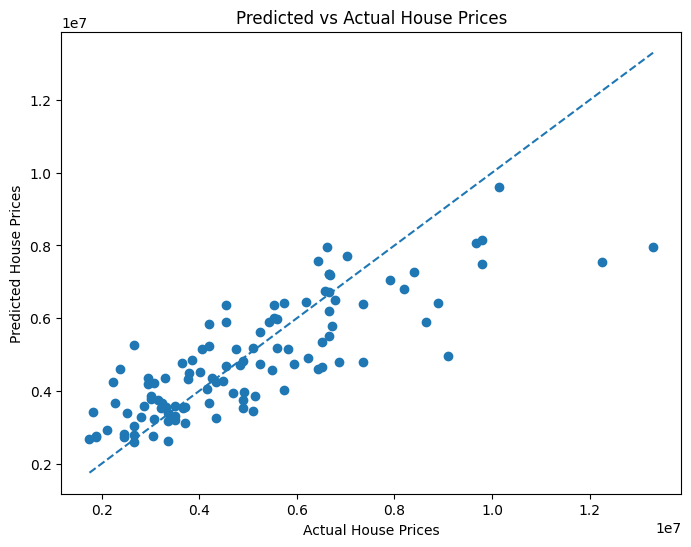

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Predicted vs Actual House Prices")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

Cell 12 — Final result

In [ ]:
print("========== FINAL RESULTS ==========")
print("Model: Linear Regression")
print("Dataset Size:", df.shape)
print("R² Score:", round(r2, 4))
print("R² Score (%):", round(r2 * 100, 2), "%")

========== FINAL RESULTS ==========
Model: Linear Regression
Dataset Size: (545, 14)
R² Score: 0.6529
R² Score (%): 65.29 %
